First, let's import OpenCV and other necessary libraries. We'll also load a sample image. Make sure you have an image file (e.g., `sample_image.jpg`) in your Colab environment or provide a valid path to an image.

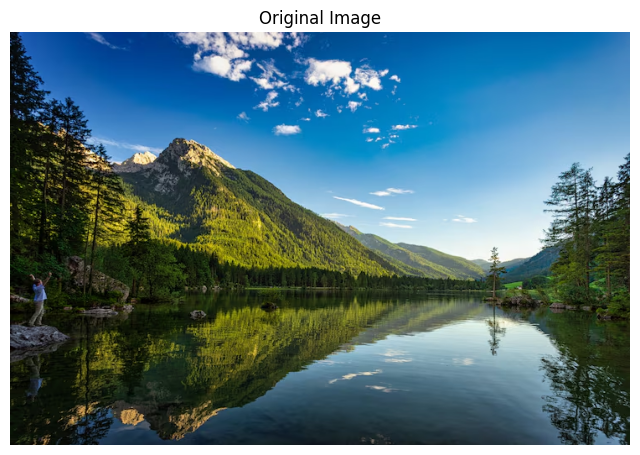

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load a sample image
# Replace 'sample_image.jpg' with the path to your image file
try:
    image = cv2.imread('park image.avif')
    if image is None:
        raise FileNotFoundError("Image not found. Please upload 'park image.avif' or provide a correct path.")

    # OpenCV loads images in BGR format, matplotlib expects RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(image_rgb)
    plt.title('Original Image')
    plt.axis('off')
    plt.show()
except FileNotFoundError as e:
    print(e)
    print("You can upload an image by clicking the folder icon on the left panel, then 'Upload to session storage'.")
except Exception as e:
    print(f"An error occurred: {e}")

Now, let's define a Region of Interest (ROI) and crop it from the image. An ROI is typically defined by its top-left corner coordinates (x, y) and its width and height.

For demonstration, I'll define a simple ROI. You can adjust the coordinates (`x`, `y`) and dimensions (`w`, `h`) to select a different area.

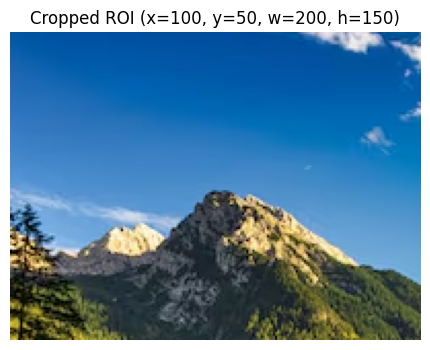

In [2]:
# Assuming 'image' is loaded from the previous cell
if 'image' in locals() and image is not None:
    # Define the ROI (x, y, width, height)
    # Adjust these values based on your image and desired ROI
    x = 100  # x-coordinate of the top-left corner
    y = 50   # y-coordinate of the top-left corner
    w = 200  # width of the ROI
    h = 150  # height of the ROI

    # Ensure ROI coordinates are within image bounds
    img_height, img_width = image.shape[:2]
    x = max(0, min(x, img_width - 1))
    y = max(0, min(y, img_height - 1))
    w = max(0, min(w, img_width - x))
    h = max(0, min(h, img_height - y))

    # Crop the image
    cropped_roi = image[y:y+h, x:x+w]

    # Display the cropped ROI
    cropped_roi_rgb = cv2.cvtColor(cropped_roi, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6, 4))
    plt.imshow(cropped_roi_rgb)
    plt.title(f'Cropped ROI (x={x}, y={y}, w={w}, h={h})')
    plt.axis('off')
    plt.show()
else:
    print("Please make sure the image is loaded in the previous cell.")

Finally, let's demonstrate copying and pasting the cropped ROI onto another location within the original image. You can specify new coordinates where you want to paste the ROI.

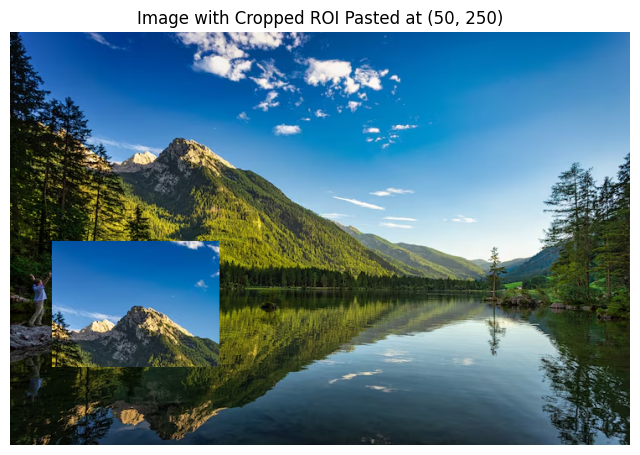

In [3]:
# Assuming 'image' and 'cropped_roi' are available from previous cells
if 'image' in locals() and image is not None and 'cropped_roi' in locals() and cropped_roi is not None:
    # Create a copy of the original image to paste onto
    image_with_paste = image.copy()

    # Define new coordinates for pasting the ROI
    # new_x: x-coordinate of the top-left corner for pasting
    # new_y: y-coordinate of the top-left corner for pasting
    new_x = 50
    new_y = 250

    # Get dimensions of the cropped ROI
    roi_h, roi_w = cropped_roi.shape[:2]

    # Ensure the paste location is within image bounds
    img_height, img_width = image_with_paste.shape[:2]

    # Calculate the actual paste dimensions to avoid going out of bounds
    paste_w = min(roi_w, img_width - new_x)
    paste_h = min(roi_h, img_height - new_y)

    if paste_w <= 0 or paste_h <= 0:
        print(f"Cannot paste ROI at ({new_x}, {new_y}) with dimensions ({roi_w}, {roi_h}) as it's out of bounds.")
    else:
        # Resize cropped_roi if it needs to be trimmed for pasting
        roi_to_paste = cropped_roi[:paste_h, :paste_w]

        # Paste the cropped ROI onto the new location
        image_with_paste[new_y : new_y + paste_h, new_x : new_x + paste_w] = roi_to_paste

        # Display the image with the pasted ROI
        image_with_paste_rgb = cv2.cvtColor(image_with_paste, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(8, 6))
        plt.imshow(image_with_paste_rgb)
        plt.title(f'Image with Cropped ROI Pasted at ({new_x}, {new_y})')
        plt.axis('off')
        plt.show()
else:
    print("Please make sure the image and cropped ROI are available from previous cells.")